<a href="https://colab.research.google.com/github/r-ballard/100r.co/blob/dev/flowerclassifier_rb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/colab_notebooks/stat6260/midterm
!ls

Mounted at /content/drive/
/content/drive/MyDrive/colab_notebooks/stat6260/midterm
Untitled0.ipynb


In [ ]:
data_dir = os.path.join(os.getcwd(),'data')
os.makedirs(data_dir, exist_ok=True)

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import scipy
import pandas as pd
import numpy as np

import re

In [ ]:
from torchvision.datasets import Flowers102
from scipy.io import loadmat

In [ ]:
torch.manual_seed(20052)

In [ ]:
os.getcwd()

'/content/drive/MyDrive/colab_notebooks/stat6260/midterm'

In [ ]:
train = Flowers102(root="data",download=True,split="train")
val = Flowers102(root="data",download=True,split="val")
test = Flowers102(root="data",download=True,split="test")

data = [train,val,test]

In [ ]:
[x for x in data]

[Dataset Flowers102
     Number of datapoints: 1020
     Root location: data
     split=train,
 Dataset Flowers102
     Number of datapoints: 1020
     Root location: data
     split=val,
 Dataset Flowers102
     Number of datapoints: 6149
     Root location: data
     split=test]

In [ ]:
mat_file_path = 'data/flowers-102/imagelabels.mat'
mat_data = scipy.io.loadmat(mat_file_path)

In [ ]:
mat_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009',
 '__version__': '1.0',
 '__globals__': [],
 'labels': array([[77, 77, 77, ..., 62, 62, 62]], dtype=uint8)}

In [ ]:
setid_file_path = 'data/flowers-102/setid.mat'
setid_data = scipy.io.loadmat(setid_file_path)

In [ ]:
setid_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 17:38:58 2009',
 '__version__': '1.0',
 '__globals__': [],
 'trnid': array([[6765, 6755, 6768, ..., 8026, 8036, 8041]], dtype=uint16),
 'valid': array([[6773, 6767, 6739, ..., 8028, 8008, 8030]], dtype=uint16),
 'tstid': array([[6734, 6735, 6737, ..., 8044, 8045, 8047]], dtype=uint16)}

In [ ]:
!ls data/flowers-102/jpg

image_00001.jpg  image_01639.jpg  image_03277.jpg  image_04915.jpg  image_06553.jpg
image_00002.jpg  image_01640.jpg  image_03278.jpg  image_04916.jpg  image_06554.jpg
image_00003.jpg  image_01641.jpg  image_03279.jpg  image_04917.jpg  image_06555.jpg
image_00004.jpg  image_01642.jpg  image_03280.jpg  image_04918.jpg  image_06556.jpg
image_00005.jpg  image_01643.jpg  image_03281.jpg  image_04919.jpg  image_06557.jpg
image_00006.jpg  image_01644.jpg  image_03282.jpg  image_04920.jpg  image_06558.jpg
image_00007.jpg  image_01645.jpg  image_03283.jpg  image_04921.jpg  image_06559.jpg
image_00008.jpg  image_01646.jpg  image_03284.jpg  image_04922.jpg  image_06560.jpg
image_00009.jpg  image_01647.jpg  image_03285.jpg  image_04923.jpg  image_06561.jpg
image_00010.jpg  image_01648.jpg  image_03286.jpg  image_04924.jpg  image_06562.jpg
image_00011.jpg  image_01649.jpg  image_03287.jpg  image_04925.jpg  image_06563.jpg
image_00012.jpg  image_01650.jpg  image_03288.jpg  image_04926.jpg  image_06

In [ ]:
#Lists images, extracts serials

files = [f for f in os.listdir('data/flowers-102/jpg') if f.endswith(".jpg")]
# Extract serial numbers using regex
serial_numbers = [re.search(r"image_(\d+)\.jpg", f).group(1) for f in files]

# Create DataFrame
df = pd.DataFrame({"filename": files, "serial_number": serial_numbers})

In [ ]:
len(set(df['serial_number']))

8189

In [ ]:
indices = np.array(mat_data['labels']).tolist()

In [ ]:
#Loads index to english name dictionary

label_mapping = pd.read_csv('data/flowers-102/oxford_flower_102_name.csv')
label_mapping

,Index,Name
0,0,pink primrose
1,1,hard-leaved pocket orchid
2,2,canterbury bells
3,3,sweet pea
4,4,english marigold
...,...,...
97,97,mexican petunia
98,98,bromelia
99,99,blanket flower
100,100,trumpet creeper


In [ ]:
#Create dictionary based on loaded csv
mapping_dict = dict(zip(label_mapping['Index'], label_mapping['Name']))

In [ ]:
new_df = pd.DataFrame({'index': indices[0]})

In [ ]:
new_df['name'] = new_df['index'].map(mapping_dict)

In [ ]:
new_df

,index,name
0,77,lotus lotus
1,77,lotus lotus
2,77,lotus lotus
3,77,lotus lotus
4,77,lotus lotus
...,...,...
8184,62,black-eyed susan
8185,62,black-eyed susan
8186,62,black-eyed susan
8187,62,black-eyed susan


In [ ]:
pivot_table = new_df['name'].value_counts().reset_index()
pivot_table.columns = ['name', 'count']

print(pivot_table)

                          name  count
0                   wild pansy    258
1                  lotus lotus    251
2                     marigold    196
3                         rose    194
4                   canna lily    184
..                         ...    ...
96            stemless gentian     40
97                  wallflower     40
98            alpine sea holly     40
99   hard-leaved pocket orchid     40
100          pincushion flower     40

[101 rows x 2 columns]


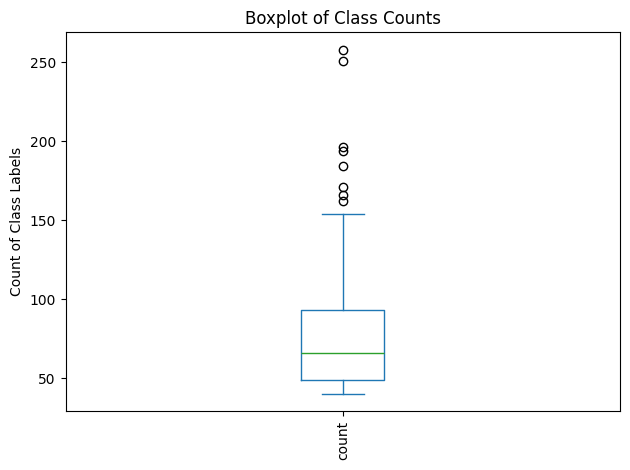

In [ ]:
pivot_table.plot(kind='box')
plt.title("Boxplot of Class Counts")
plt.ylabel("Count of Class Labels")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 2500x1000 with 0 Axes>

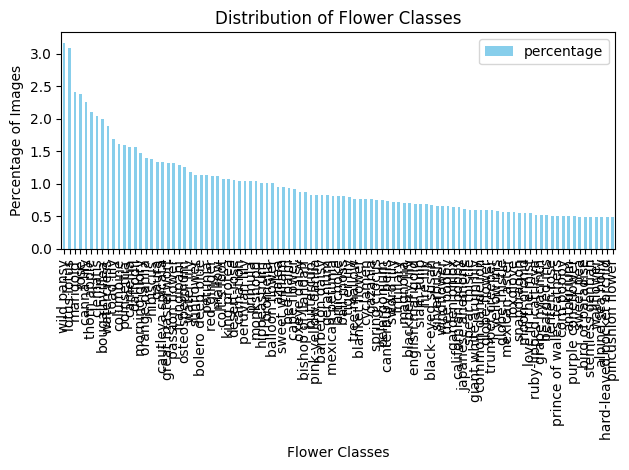

In [ ]:
pivot_table_percent = new_df['name'].value_counts(normalize=True) * 100
pivot_table_percent = pivot_table_percent.reset_index()
pivot_table_percent.columns = ['name', 'percentage']
pivot_table_percent.set_index('name', inplace=True)

classfig = plt.figure(figsize = (50,10))
pivot_table_percent.plot(kind='bar', color='skyblue')
plt.title("Distribution of Flower Classes")
plt.xlabel("Flower Classes")
plt.ylabel("Percentage of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
pivot_table_percent

,proportion
name,
wild pansy,3.169144
lotus lotus,3.083159
marigold,2.407567
rose,2.383000
canna lily,2.260165
...,...
stemless gentian,0.491340
wallflower,0.491340
alpine sea holly,0.491340
